## 1. Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Paths

In [20]:
BASE_PATH = "/content/drive/MyDrive/job-posting-classifier"

DATA_PROCESSED = BASE_PATH + "/data/processed/cleaned_data.csv"
SVM_MODEL_PATH = BASE_PATH + "/models/svm_model.pkl"
TFIDF_PATH = BASE_PATH + "/models/tfidf_vectorizer.pkl"
BERT_MODEL_PATH = BASE_PATH + "/models/distilbert_model"
META_MODEL_PATH = BASE_PATH + "/models/meta_model.pkl"

## 3. Install Libraries

In [3]:
!pip install transformers torch joblib

## 4. Import Libraries

In [17]:
import torch
import numpy as np
import pandas as pd
import joblib

from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch.nn.functional as F

## 5. Load Model and Tokenizer

In [5]:
import os

os.listdir("/content/drive/MyDrive/job-posting-classifier/models/distilbert_model")

['config.json', 'model.safetensors', 'tokenizer_config.json', 'tokenizer.json']

In [6]:
# Load SVM + TFIDF + Meta model
svm_model = joblib.load(SVM_MODEL_PATH)
tfidf = joblib.load(TFIDF_PATH)
meta_model = joblib.load(META_MODEL_PATH)

# Load BERT
tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_PATH, local_files_only=True)
bert_model = AutoModelForSequenceClassification.from_pretrained(BERT_MODEL_PATH, local_files_only=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
bert_model.to(device)
bert_model.eval()

print("All models loaded successfully")

Loading weights:   0%|          | 0/106 [00:01<?, ?it/s]

All models loaded successfully


In [7]:
# classes = [
#     "Contract",
#     "Full-time",
#     "Internship",
#     "Other",
#     "Part-time"
# ]

In [8]:
def predict_job_type(text):

    # -------- SVM --------
    text_tfidf = tfidf.transform([text])
    svm_prob = svm_model.predict_proba(text_tfidf)

    # -------- BERT --------
    inputs = tokenizer(
        text,
        truncation=True,
        padding=True,
        max_length=192,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = bert_model(**inputs)

    bert_prob = torch.softmax(outputs.logits, dim=1).cpu().numpy()

    # -------- Ensemble --------
    meta_input = np.hstack((bert_prob, svm_prob))

    # Final prediction
    prediction = meta_model.predict(meta_input)[0]

    # -------- Confidence + Top Predictions --------
    probs = meta_model.predict_proba(meta_input)[0]
    classes = meta_model.classes_

    confidence = float(np.max(probs))

    # Top 3 predictions
    top_indices = np.argsort(probs)[::-1][:3]

    top_predictions = []
    for i in top_indices:
        top_predictions.append((classes[i], round(probs[i], 3)))

    return prediction, confidence, top_predictions

In [9]:
text = "Looking for a part-time sales associate for weekend shifts"
label, conf, top_preds = predict_job_type(text)

print("Prediction:", label)
print("Confidence:", round(conf, 3))

print("\nTop Predictions:")
for cls, prob in top_preds:
    print(cls, ":", prob)

Prediction: Part-time
Confidence: 0.757

Top Predictions:
Part-time : 0.757
Full-time : 0.195
Other : 0.022


In [10]:
while True:
    text = input("Enter job description (or type 'exit'): ")

    if text.lower() == "exit":
        break

    label, conf, top_preds = predict_job_type(text)

    print("Predicted Job Type:", label)
    print("Confidence:", round(conf, 3))

    print("\nTop Predictions:")
    for cls, prob in top_preds:
        print(f"{cls}: {prob}")

    print("\n" + "-"*40)

Enter job description (or type 'exit'): exit


In [28]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_PATH)

# Load model
model = AutoModelForSequenceClassification.from_pretrained(BERT_MODEL_PATH)

# Device setup
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()

print("BERT model loaded")

Loading weights:   0%|          | 0/106 [00:00<?, ?it/s]

BERT model loaded


In [29]:
def predict(texts):

    # ensure correct format
    if isinstance(texts, np.ndarray):
        texts = texts.tolist()

    texts = [str(t) for t in texts]

    inputs = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    return outputs.logits.cpu().numpy()

In [30]:
import shap

# Load data
df = pd.read_csv(DATA_PROCESSED)
X = df["text"]

# SVM Explainer
svm_explainer = shap.LinearExplainer(
    svm_model,
    tfidf.transform(X[:100])
)

# BERT Explainer
bert_explainer = shap.Explainer(predict, tokenizer)

In [36]:
def full_prediction(text):

    print("\n==============================")
    print("INPUT:", text)
    print("==============================")

    # 🔹 Prediction
    label, conf, top_preds = predict_job_type(text)

    print("\n🔹 Prediction:", label)
    print("🔹 Confidence:", round(conf, 3))

    print("\n🔹 Top Predictions:")
    for cls, prob in top_preds:
        print(cls, ":", prob)

    # =========================================================
    # 🔹 SVM Explanation (WORDS INSTEAD OF FEATURE NUMBERS)
    # =========================================================
    print("\n🔹 SVM Important Words:")

    sample_vec = tfidf.transform([text])
    feature_names = tfidf.get_feature_names_out()

    shap_values_svm = svm_explainer(sample_vec)
    pred_class_svm = np.argmax(svm_model.predict_proba(sample_vec))

    values = shap_values_svm.values[0][:, pred_class_svm]
    sample_dense = sample_vec.toarray()[0]

    indices = np.where(sample_dense != 0)[0]

    words = feature_names[indices]
    word_values = values[indices]

    top_indices = np.argsort(np.abs(word_values))[::-1][:10]

    for i in top_indices:
        print(words[i], ":", round(word_values[i], 3))

    # =========================================================
    # 🔹 BERT Explanation
    # =========================================================
    print("\n🔹 BERT Explanation (Context):")

    shap_values_bert = bert_explainer([text])
    pred_class_bert = np.argmax(predict([text]))

    shap.plots.waterfall(shap_values_bert[0, :, pred_class_bert])

    # =========================================================
    # 🔹 BERT Important Words
    # =========================================================
    print("\n🔹 Important Words (BERT):")

    tokens = list(shap_values_bert.data[0])
    values = np.array(shap_values_bert.values[0][:, pred_class_bert])

    min_len = min(len(tokens), len(values))
    tokens = tokens[:min_len]
    values = values[:min_len]

    top_indices = np.argsort(np.abs(values))[::-1][:10]

    for i in top_indices:
        print(tokens[i], ":", round(values[i], 3))


INPUT: Looking for a part-time retail sales associate for weekend shifts

🔹 Prediction: Part-time
🔹 Confidence: 0.899

🔹 Top Predictions:
Part-time : 0.899
Full-time : 0.071
Contract : 0.013

🔹 SVM Important Words:
retail : 0.308
time retail : 0.236
time : 0.21
shifts : 0.205
weekend : 0.2
sales associate : 0.17
sales : -0.141
retail sales associate : 0.131
retail sales : 0.029
associate : 0.013

🔹 BERT Explanation (Context):


  0%|          | 0/132 [00:00<?, ?it/s]

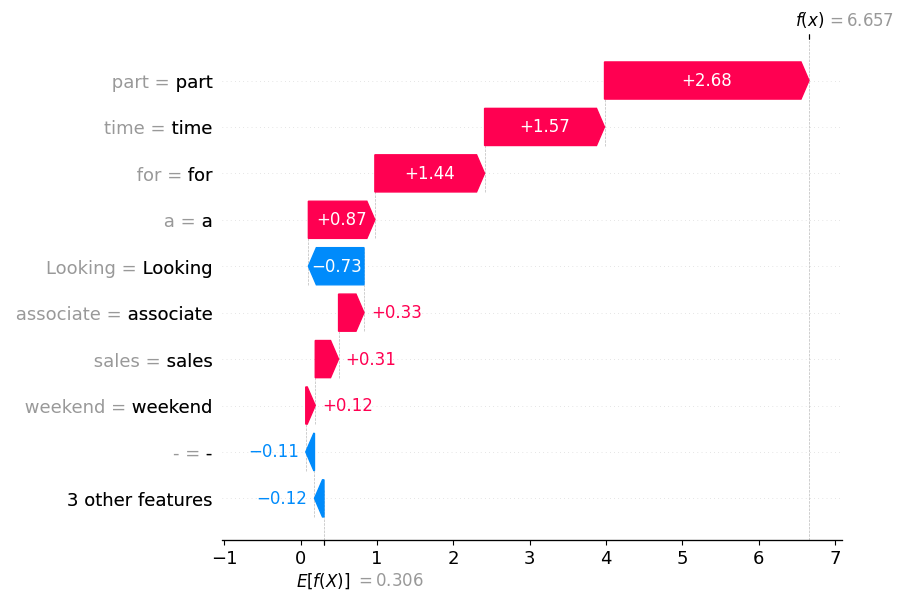


🔹 Important Words (BERT):
 part : 2.678
time : 1.57
 for : 1.437
 a : 0.871
Looking : -0.729
 associate : 0.333
 sales : 0.305
 weekend : 0.124
- : -0.114
 retail : -0.087


In [37]:
full_prediction("Looking for a part-time retail sales associate for weekend shifts")